In [12]:


import numpy as np

# 1. Création de tableaux
a = np.arange(10)              # [0, 1, 2, ..., 9]
print(a.shape, a.dtype, a.ndim, a.size)
# → (10,) int64 1 10

b = np.linspace(0, 2*np.pi, 7)  # 7 pts entre 0 et 2π
print(b.shape)                   # → (7,)

z = np.zeros((3, 4))             # matrice 3×4 de zéros
o = np.ones((3, 4))              # matrice 3×4 de uns

# 2. arange vs linspace
print(np.arange(0, 1, 0.1).size)   # 10 pts (mais instable en float)
print(np.linspace(0, 1, 10).size)  # 10 pts GARANTI, inclut 1.0

# 3. Nombres aléatoires
r1 = np.random.rand(20)                  # [0, 1[
r2 = np.random.uniform(10, 50, 20)       # [10, 50]

# 4. Tableau des carrés
carres = np.arange(1, 8) ** 2           # [1, 4, 9, 16, 25, 36, 49]

# 5. Autres fonctions
np.full((2, 3), 7)       # matrice 2×3 remplie de 7
np.eye(4)                # matrice identité 4×4
np.diag([1, 2, 3, 4])    # matrice diagonale



(10,) int64 1 10
(7,)
10
10


array([[1, 0, 0, 0],
       [0, 2, 0, 0],
       [0, 0, 3, 0],
       [0, 0, 0, 4]])

In [13]:
import numpy as np

# 1. Fonctions vectorisées
x   = np.linspace(-np.pi, np.pi, 100)
sx  = np.sin(x)    # sin sur les 100 valeurs d'un coup
cx  = np.cos(x)
ex  = np.exp(x)
abx = np.abs(x)

# 2. Identité sin²+cos²=1
identite = sx**2 + cx**2
print(np.allclose(identite, 1))  # → True (tolérance numérique)

# 3. Dérivée numérique de sin ≈ cos
# diff(sin(x)) / diff(x) ≈ cos(x)
dx          = x[1] - x[0]          # pas de discrétisation
derivee_sin = np.diff(sx) / dx      # longueur n-1
cos_milieux = np.cos((x[:-1] + x[1:]) / 2)
print(np.allclose(derivee_sin, cos_milieux, atol=1e-4))  # → True

# 4. Polynôme sans boucle
t = np.linspace(-5, 5, 50)
f = 3*t**2 - 2*t + 1   # appliqué sur 50 valeurs

# 5. Broadcasting : M[i,j] = i + j
i = np.arange(5).reshape(5, 1)   # colonne (5,1)
j = np.arange(5)                  # ligne   (1,5)
M = i + j                          # broadcasting → (5,5)
print(M)

True
False
[[0 1 2 3 4]
 [1 2 3 4 5]
 [2 3 4 5 6]
 [3 4 5 6 7]
 [4 5 6 7 8]]


In [14]:


import numpy as np

A = np.array([[2, 1], [5, 3]])
B = np.array([[4, 0], [1, 2]])

# 1. Opérations
print(A + B)        # addition élement par élement
print(A * B)        # ✗ mult. ÉLÉMENT PAR ÉLÉMENT (pas matriciel !)
print(A @ B)        # ✓ PRODUIT MATRICIEL (équivalent à np.dot(A, B))
print(np.dot(A, B))  # identique à A @ B

# 2. Transposée
print(A.T)           # ou np.transpose(A)
# Vérification (A@B)ᵀ = Bᵀ@Aᵀ
print(np.allclose((A@B).T, B.T @ A.T))  # → True

# 3. Déterminant et inverse
det_A = np.linalg.det(A)
inv_A = np.linalg.inv(A)
print(f"det(A) = {det_A:.1f}")            # → 1.0
print(np.allclose(A @ inv_A, np.eye(2)))  # → True

# 4. Trace, valeurs et vecteurs propres
print(f"trace(A) = {np.trace(A)}")         # = 2+3 = 5
val_p, vec_p = np.linalg.eig(A)
print("Valeurs propres :", val_p)
print("Vecteurs propres :\n", vec_p)

# 5. Résolution de système Ax = b
b = np.array([1, 2])
x = np.linalg.solve(A, b)
print("Solution x =", x)
print("Vérification A@x =", A@x)         # doit donner [1, 2]



[[6 1]
 [6 5]]
[[8 0]
 [5 6]]
[[ 9  2]
 [23  6]]
[[ 9  2]
 [23  6]]
[[2 5]
 [1 3]]
True
det(A) = 1.0
True
trace(A) = 5
Valeurs propres : [0.20871215 4.79128785]
Vecteurs propres :
 [[-0.48744474 -0.33726692]
 [ 0.87315384 -0.94140906]]
Solution x = [ 1. -1.]
Vérification A@x = [1. 2.]


In [15]:
import numpy as np

M = np.arange(1, 25).reshape(4, 6)

# 1. Slicing 2D : [ligne, colonne]
M[1, :]          # 2e ligne complète
M[:, 2]          # 3e colonne complète
M[2:, 4:]        # coin bas-droite 2×2
M[::, ::2]       # colonnes paires (0, 2, 4)

# 2. Masque booléen
Mc = M.copy()
masque = Mc > 12
Mc[masque] = 0   # ← modification avec masque


# 3. Reshape
M.flatten()           # → tableau 1D (copie)
M.reshape(6, 4)       # → 6×4
M.reshape(2, 3, 4)    # → tenseur 3D

# 4. Stack / split
A = np.ones((2, 3))
B = np.zeros((2, 3))
V = np.vstack([A, B])  # empilement vertical → (4,3)
H = np.hstack([A, B])  # empilement horizontal → (2,6)
p1, p2 = np.split(V, 2)  # découpe en 2 parties égales

# 5. Argsort
flat    = M.flatten()
indices = np.argsort(flat)[-3:][::-1]  # 3 plus grands
print("Top 3 indices :", indices, "valeurs :", flat[indices])

Top 3 indices : [23 22 21] valeurs : [24 23 22]


In [16]:
import numpy as np

notes = np.array([[14,16,12,18],[9,11,8,13],
                   [17,15,19,16],[10,12,9,11],[20,18,17,19]])

# 1. Moyennes
moy_etud = notes.mean(axis=1)   # par étudiant (5 valeurs)
moy_exam = notes.mean(axis=0)   # par examen  (4 valeurs)
print("Moy. étudiants :", np.round(moy_etud, 2))
print("Moy. examens   :", np.round(moy_exam, 2))

# 2. Examen + difficile, étudiant + fort
exam_dur  = np.argmin(moy_exam) + 1
etud_fort = np.argmax(moy_etud) + 1
print(f"Examen le plus dur : Examen {exam_dur}")
print(f"Étudiant le + fort : Étudiant {etud_fort}")

# 3. Écart-type par examen
std_exam   = notes.std(axis=0)
plus_dispe = np.argmax(std_exam) + 1
print(f"Plus dispersé : Examen {plus_dispe} (σ={std_exam.max():.2f})")

# 4. Nombre d'étudiants avec moy ≥ 14
admis = np.sum(moy_etud >= 14)
print(f"Étudiants ≥ 14 : {admis}/{len(moy_etud)}")

# 5. Matrice de corrélation entre examens
corr = np.corrcoef(notes.T)   # .T pour correlcorr entre colonnes
print("\nMatrice de corrélation :")
print(np.round(corr, 2))

# 6. Normalisation 0→20
notes_norm = (notes / notes.max()) * 20
print(np.round(notes_norm, 1))

Moy. étudiants : [15.   10.25 16.75 10.5  18.5 ]
Moy. examens   : [14.  14.4 13.  15.4]
Examen le plus dur : Examen 3
Étudiant le + fort : Étudiant 5
Plus dispersé : Examen 3 (σ=4.34)
Étudiants ≥ 14 : 3/5

Matrice de corrélation :
[[1.   0.94 0.92 0.85]
 [0.94 1.   0.77 0.93]
 [0.92 0.77 1.   0.69]
 [0.85 0.93 0.69 1.  ]]
[[14. 16. 12. 18.]
 [ 9. 11.  8. 13.]
 [17. 15. 19. 16.]
 [10. 12.  9. 11.]
 [20. 18. 17. 19.]]


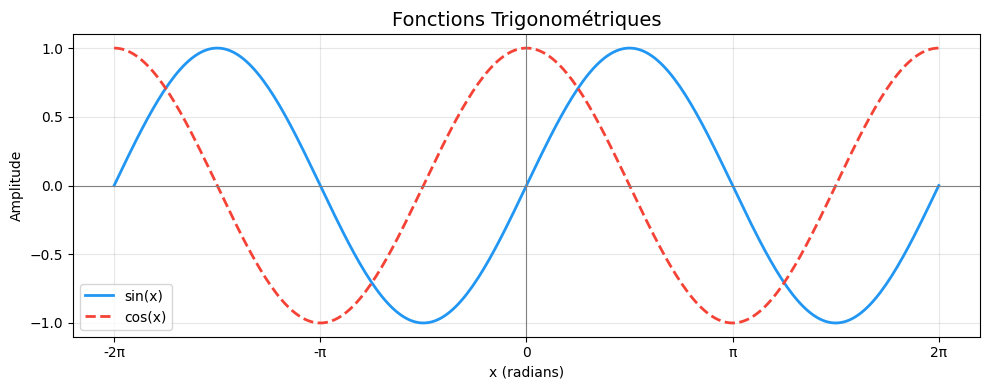

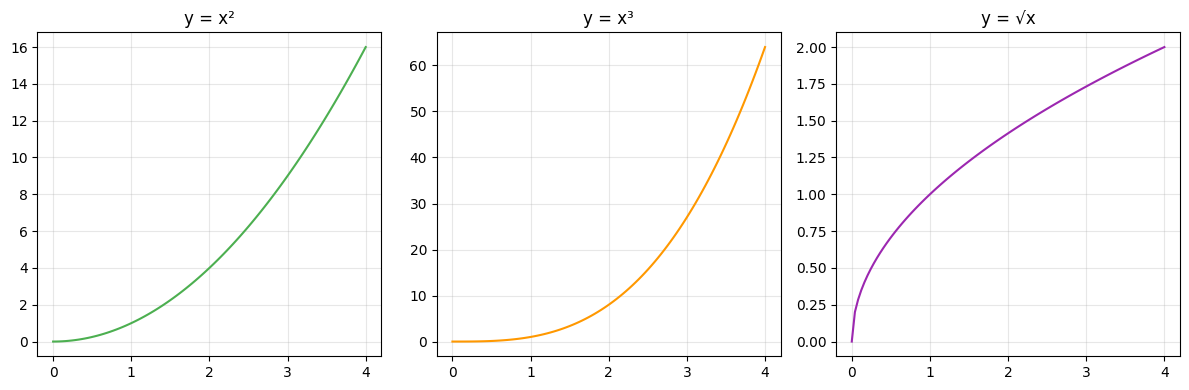

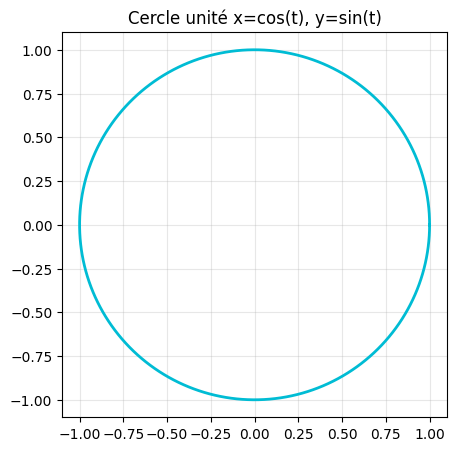

In [17]:


import numpy as np
import matplotlib.pyplot as plt

# 1. sin et cos sur le même graphique
x = np.linspace(-2*np.pi, 2*np.pi, 300)

plt.figure(figsize=(10, 4))
plt.plot(x, np.sin(x), label="sin(x)", color="#2196F3", lw=2)
plt.plot(x, np.cos(x), label="cos(x)", color="#F44336", lw=2, linestyle="--")
plt.axhline(0, color="gray", lw=0.8)   # ligne y=0
plt.axvline(0, color="gray", lw=0.8)   # ligne x=0
plt.title("Fonctions Trigonométriques", fontsize=14)
plt.xlabel("x (radians)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks([-2*np.pi, -np.pi, 0, np.pi, 2*np.pi],
           ["-2π", "-π", "0", "π", "2π"])
plt.yticks([-1,-0.5,0,0.5,1])
plt.tight_layout()
plt.savefig("sincos.png", dpi=150)
plt.show()

# 2. Sous-graphiques (subplots)
x2 = np.linspace(0, 4, 100)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(x2, x2**2, color="#4CAF50"); axes[0].set_title("y = x²")
axes[1].plot(x2, x2**3, color="#FF9800"); axes[1].set_title("y = x³")
axes[2].plot(x2, np.sqrt(x2), color="#9C27B0"); axes[2].set_title("y = √x")
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 3. Courbe paramétrée — Cercle
t = np.linspace(0, 2*np.pi, 200)
plt.figure(figsize=(5, 5))
plt.plot(np.cos(t), np.sin(t), lw=2, color="#00BCD4")
plt.gca().set_aspect("equal")
plt.title("Cercle unité x=cos(t), y=sin(t)")
plt.grid(alpha=0.3); plt.show()



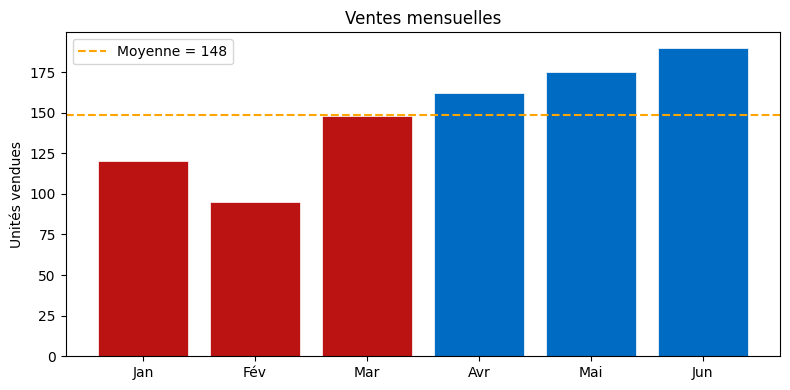

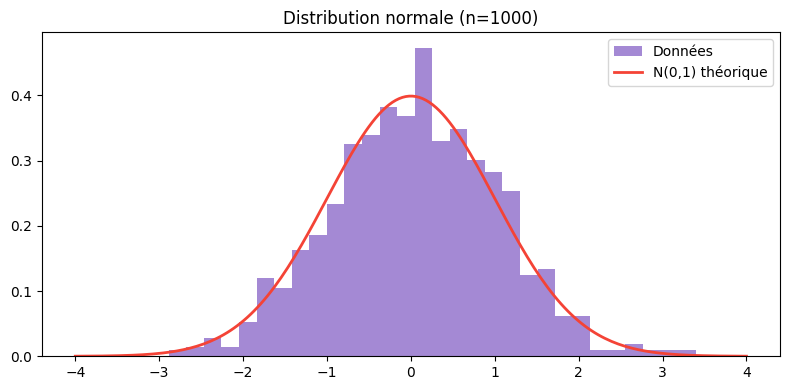

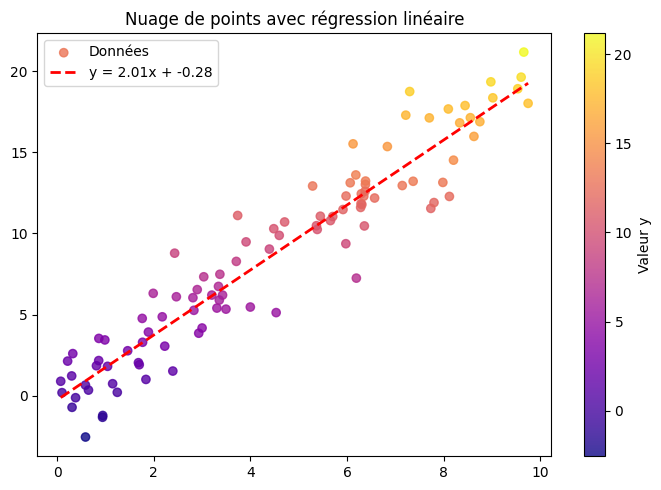

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Barres avec couleurs conditionnelles
mois   = ["Jan","Fév","Mar","Avr","Mai","Jun"]
ventes = np.array([120, 95, 148, 162, 175, 190])
moy    = ventes.mean()
colors = ["#BB1212" if v < moy else "#006bc2" for v in ventes]

plt.figure(figsize=(8, 4))
plt.bar(mois, ventes, color=colors, edgecolor="white", lw=0.5)
plt.axhline(moy, color="orange", linestyle="--", label=f"Moyenne = {moy:.0f}")
plt.title("Ventes mensuelles"); plt.ylabel("Unités vendues")
plt.legend(); plt.tight_layout(); plt.show()

# 2. Histogramme loi normale + densité
from scipy.stats import norm

data = np.random.randn(1000)
xr   = np.linspace(-4, 4, 200)

plt.figure(figsize=(8, 4))
plt.hist(data, bins=30, density=True, color="#7e57c2", alpha=0.7, label="Données")
plt.plot(xr, norm.pdf(xr), color="#f44336", lw=2, label="N(0,1) théorique")
plt.title("Distribution normale (n=1000)")
plt.legend(); plt.tight_layout(); plt.show()

# 3. Nuage de points avec régression
x    = np.random.uniform(0, 10, 100)
y    = 2*x + np.random.randn(100) * 2
coef = np.polyfit(x, y, 1)     # régression linéaire
droite = np.polyval(coef, x)   # valeurs de la droite

plt.figure(figsize=(7, 5))
plt.scatter(x, y, c=y, cmap="plasma", alpha=0.8, label="Données")
plt.plot(np.sort(x), np.sort(droite), "r--", lw=2,
        label=f"y = {coef[0]:.2f}x + {coef[1]:.2f}")
plt.colorbar(label="Valeur y")
plt.title("Nuage de points avec régression linéaire")
plt.legend(); plt.tight_layout(); plt.show()

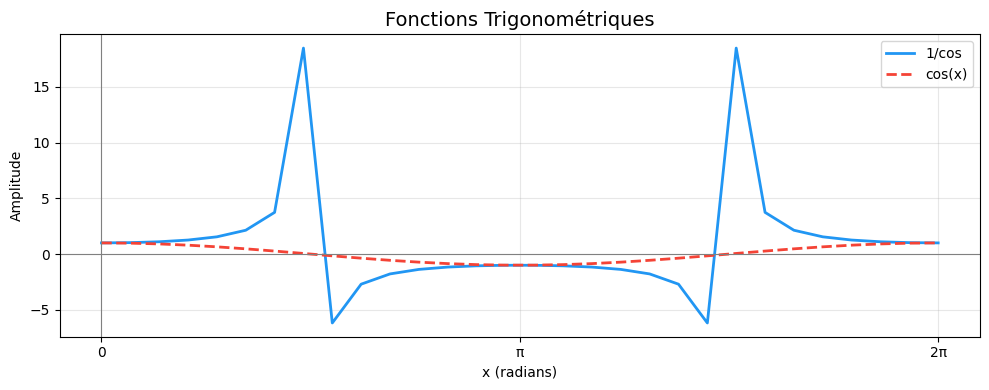

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 1/cos et cos sur le même graphique
x = np.linspace(0, 2*np.pi, 30)

plt.figure(figsize=(10, 4))
plt.plot(x, 1/ np.cos(x), label="1/cos", color="#2196F3", lw=2)
plt.plot(x, np.cos(x), label="cos(x)", color="#F44336", lw=2, linestyle="--")
plt.axhline(0, color="gray", lw=0.8)   # ligne y=0
plt.axvline(0, color="gray", lw=0.8)   # ligne x=0
plt.title("Fonctions Trigonométriques", fontsize=14)
plt.xlabel("x (radians)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks([ 0, np.pi, 2*np.pi],
           ["0", "π", "2π"])
plt.tight_layout()
plt.savefig("sincos.png", dpi=150)
plt.show()

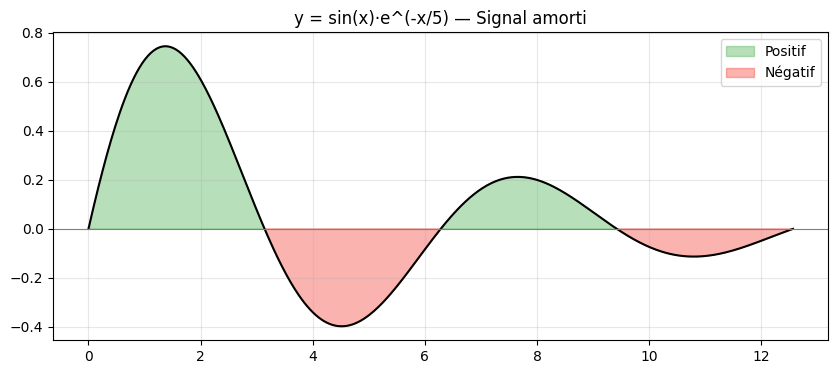

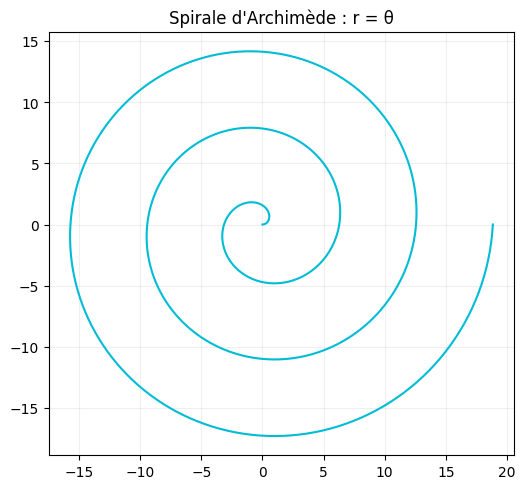

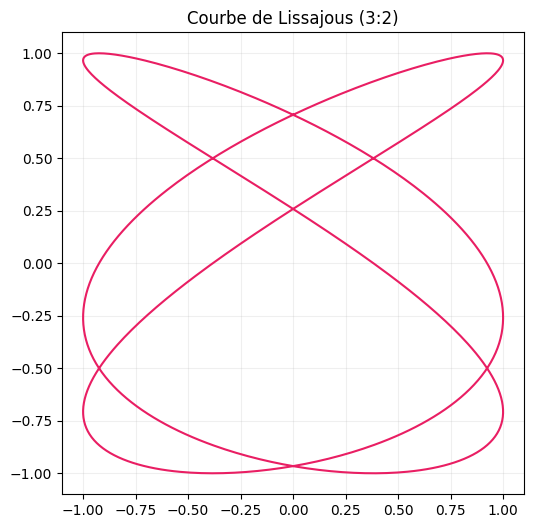

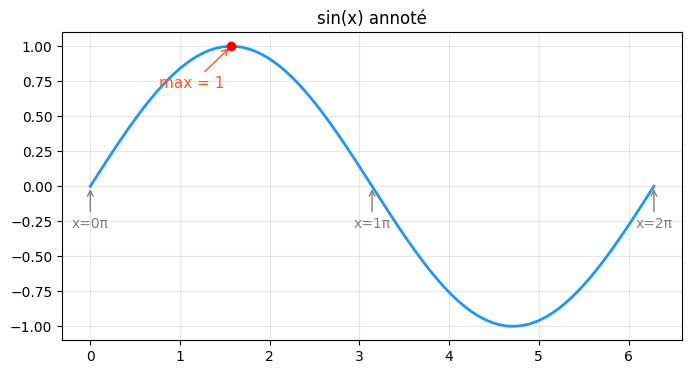

In [20]:

import numpy as np
import matplotlib.pyplot as plt

# 1. Amortissement avec fill_between
x = np.linspace(0, 4*np.pi, 500)
y = np.sin(x) * np.exp(-x/5)

plt.figure(figsize=(10, 4))
plt.plot(x, y, "k", lw=1.5)
plt.fill_between(x, y, 0, where=(y > 0),
                 color="#4caf50", alpha=0.4, label="Positif")
plt.fill_between(x, y, 0, where=(y < 0),
                 color="#f44336", alpha=0.4, label="Négatif")
plt.axhline(0, color="gray", lw=0.8)
plt.title("y = sin(x)·e^(-x/5) — Signal amorti")
plt.legend(); plt.grid(alpha=0.3); plt.show()

# 2. Spirale d'Archimède
theta = np.linspace(0, 6*np.pi, 500)
r     = theta
plt.figure(figsize=(6, 6))
plt.plot(r*np.cos(theta), r*np.sin(theta), lw=1.5, color="#00bcd4")
plt.gca().set_aspect("equal")
plt.title("Spirale d'Archimède : r = θ")
plt.grid(alpha=0.2); plt.show()

# 3. Courbe de Lissajous
t = np.linspace(0, 2*np.pi, 1000)
plt.figure(figsize=(6, 6))
plt.plot(np.sin(3*t), np.sin(2*t + np.pi/4),
        lw=1.5, color="#e91e63")
plt.gca().set_aspect("equal")
plt.title("Courbe de Lissajous (3:2)")
plt.grid(alpha=0.2); plt.show()

# 4. Annotations des zéros et maxima
x = np.linspace(0, 2*np.pi, 300)
y = np.sin(x)
plt.figure(figsize=(8, 4))
plt.plot(x, y, lw=2, color="#2196f3")

# Zéros à x=0, π, 2π
for xz in [0, np.pi, 2*np.pi]:
    plt.annotate(f"x={xz/np.pi:.0f}π", xy=(xz, 0),
                xytext=(xz, -0.3), ha="center", color="gray",
                arrowprops=dict(arrowstyle="->", color="gray"))
# Maximum à x=π/2
plt.annotate("max = 1", xy=(np.pi/2, 1),
            xytext=(np.pi/2 - 0.8, 0.7), color="#ff5722", fontsize=11,
            arrowprops=dict(arrowstyle="->", color="#ff5722"))
plt.scatter([np.pi/2], [1], color="red", zorder=5)
plt.title("sin(x) annoté")
plt.grid(alpha=0.3); plt.show()



Convergence de ∫₀^π sin(x)dx :
  n=10  → [ 5.67128182 14.13716694]  erreur=[ 3.67128182 12.13716694]
  n=100  → [ 63.0200685  155.50883635]  erreur=[ 61.0200685  153.50883635]
  n=1000  → [ 635.98262847 1569.22553047]  erreur=[ 633.98262847 1567.22553047]
  n=10000  → [ 6365.56105154 15706.39247162]  erreur=[ 6363.56105154 15704.39247162]


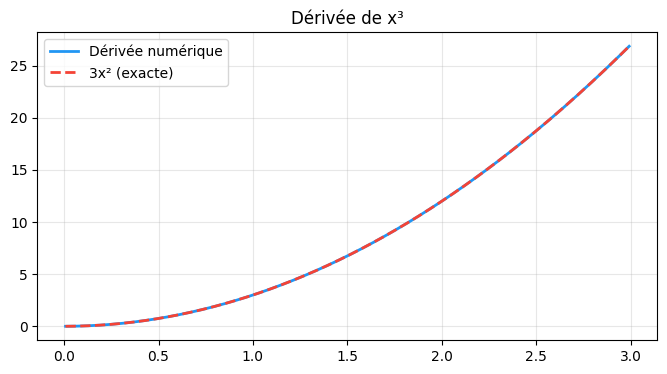

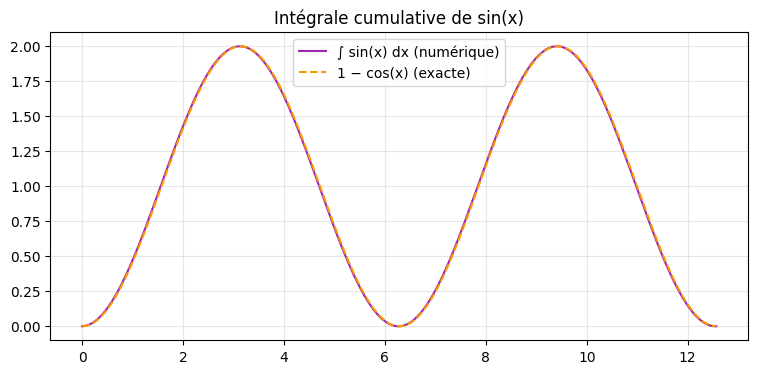

Distance numérique : 105.0001 m
Distance exacte    : 105.0000 m


In [21]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Intégration par trapèzes
print("Convergence de ∫₀^π sin(x)dx :")
for n in [10, 100, 1000, 10000]:
    x    = np.linspace(0, np.pi, n)
    res  = np.trapezoid((np.sin(x), x))
    err  = abs(res - 2.0)
    print(f"  n={n}  → {res}  erreur={err}")

# 2. Dérivée numérique de x³ vs 3x²
x    = np.linspace(0, 3, 200)
f    = x**3
dx   = x[1] - x[0]
df   = np.diff(f) / dx         # dérivée numérique (n-1 points)
xm   = (x[:-1] + x[1:]) / 2   # milieux des intervalles
exact= 3 * xm**2               # dérivée exacte 3x²

plt.figure(figsize=(8, 4))
plt.plot(xm, df,    label="Dérivée numérique", lw=2, color="#2196f3")
plt.plot(xm, exact, label="3x² (exacte)", lw=2, linestyle="--", color="#f44336")
plt.title("Dérivée de x³"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

# 3. Intégrale cumulative de sin(x)
x    = np.linspace(0, 4*np.pi, 400)
s    = np.sin(x)
dx   = x[1] - x[0]
integ= np.cumsum(s) * dx      # ≈ ∫₀^x sin(t)dt = 1-cos(x)
exact_int = 1 - np.cos(x)

plt.figure(figsize=(9, 4))
plt.plot(x, integ,      label="∫ sin(x) dx (numérique)", color="#9c27b0")
plt.plot(x, exact_int,  label="1 − cos(x) (exacte)",    color="#ff9800", ls="--")
plt.title("Intégrale cumulative de sin(x)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

# 4. Distance = ∫ v(t) dt
t    = np.linspace(0, 5, 1000)
v    = 3*t**2 - 2*t + 1         # vitesse
d    = np.trapezoid(v, t)            # distance = intégrale de v
d_exact = 5**3 - 5**2 + 5      # = t³-t²+t évalué en 5
print(f"Distance numérique : {d:.4f} m")
print(f"Distance exacte    : {d_exact:.4f} m")

Fréquences détectées : [ 5 12 25] Hz


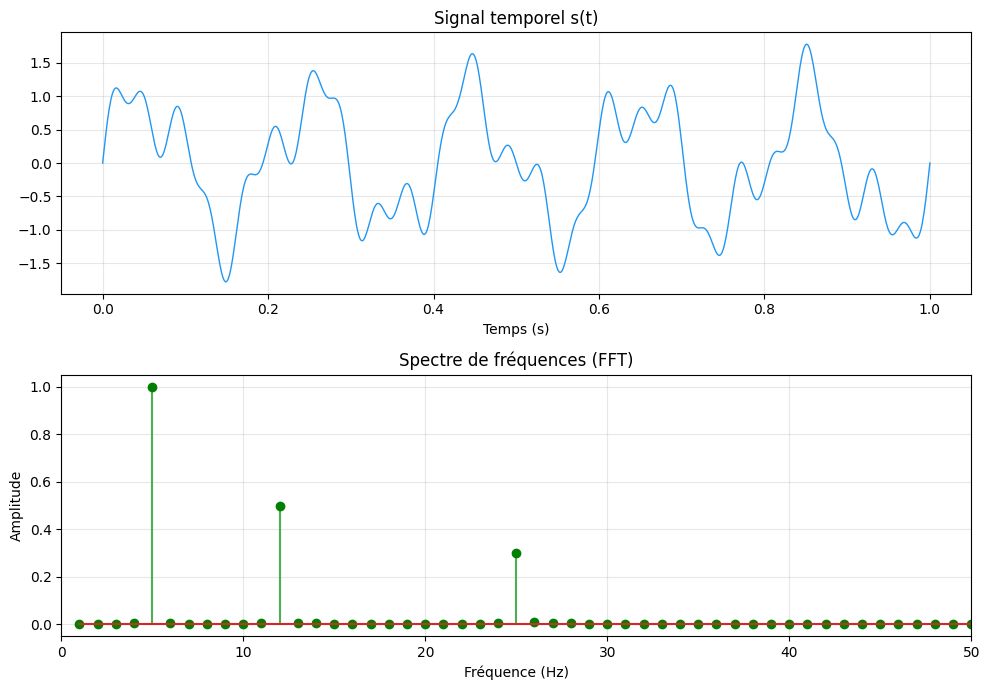

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Création du signal composite
N  = 1000                        # nombre de points
T  = 1.0                         # durée : 1 seconde
t  = np.linspace(0, T, N)
s  = (np.sin(2*np.pi*5*t)
    + 0.5*np.sin(2*np.pi*12*t)
    + 0.3*np.sin(2*np.pi*25*t))

# 2. FFT
S    = np.fft.fft(s)             # transformée de Fourier
freqs= np.fft.fftfreq(N, T/N)   # fréquences en Hz
amp  = np.abs(S) / N            # amplitude normalisée

# On ne garde que les fréquences positives
mask  = freqs > 0
freqs_pos = freqs[mask]
amp_pos   = 2 * amp[mask]       # ×2 car symétrie

# 3. Graphique double
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))

ax1.plot(t, s, color="#2196f3", lw=1)
ax1.set_title("Signal temporel s(t)"); ax1.set_xlabel("Temps (s)")
ax1.grid(alpha=0.3)

ax2.stem(freqs_pos, amp_pos, "#4caf50", markerfmt="go")
ax2.set_xlim(0, 50)
ax2.set_title("Spectre de fréquences (FFT)")
ax2.set_xlabel("Fréquence (Hz)"); ax2.set_ylabel("Amplitude")
ax2.grid(alpha=0.3)

# 4. Identifier les pics
pics = freqs_pos[np.argsort(amp_pos)[-3:][::-1]]
print(f"Fréquences détectées : {np.sort(pics).astype(int)} Hz")
# → [5, 12, 25]
plt.tight_layout(); plt.show()